In [68]:
# Import the protocol files
import os
import sys
sys.path.append(os.path.abspath('../../')) 
from protocol import ScoreSpectra, BayesianOptimization,GaussianProcess, PlotGP, MaraData,TxtToCsvConverter

# Import necessary libraries
import pandas as pd
import numpy as np
import torch
from importlib import reload
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from scipy.stats import qmc
import random

dtype = torch.float64

In [69]:
# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N2 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 1.00,  
                  'R MAI': 1.50,
                  'R PbI2': 1,
                  }

# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N1 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 2.00,  
                  'R MAI': 2.00,
                  'R PbI2': 1,
                  }

# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N3 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 0.667,  # aprox to 0.675
                  'R MAI': 1.333, # aprox to 1.325
                  'R PbI2': 1,
                  }

theoretical_N4 = {'Anneal Time': 10, # min
                  'Temperature': 95, # C
                  'R BAAc': 0.5,  
                  'R MAI': 1.25,
                  'R PbI2': 1,
                  }

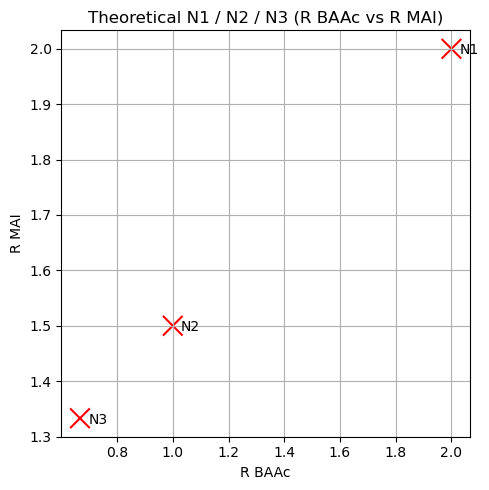

In [70]:
# N1 Initial
# Containts N1, N2, and N3 theoretical

# create a small dataframe with the theoretical points and plot them (2D + 3D)
theo_df = pd.DataFrame([theoretical_N1, theoretical_N2, theoretical_N3], index=['N1', 'N2', 'N3'])

# 2D scatter: R BAAc vs R MAI, color by Temperature, size by R PbI2
plt.figure(figsize=(5,5))
sc = plt.scatter(theo_df['R BAAc'], theo_df['R MAI'],
                s=200*theo_df['R PbI2'], color ='r' , marker='x')
for i, lab in enumerate(theo_df.index):
    plt.annotate(lab, (theo_df['R BAAc'].iloc[i], theo_df['R MAI'].iloc[i]),
                 textcoords="offset points", xytext=(6,-4))
plt.xlabel('R BAAc')
plt.ylabel('R MAI')
# cbar = plt.colorbar(sc)
# cbar.set_label('Temperature (°C)')
plt.title('Theoretical N1 / N2 / N3 (R BAAc vs R MAI)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
N1_data = pd.read_csv('../N1_Campaign/Data/N1Campaign_data.csv')
N2_data = pd.read_csv('../N2_Campaign/Data/N2Campaign_data.csv')
N3_data = pd.read_csv('../N3_Campaign/Data/N3Campaign_data.csv')

In [72]:
def plot_convergence(data, qw_col, color ='tab:blue'):
    # group data by round extracted from the 'files' column and plot QW 1 per round
    data = data.copy()  # avoid mutating original reference
    data['round'] = data['files'].str.extract(r'R(\d+)', expand=False).astype(int)

    # optional: inspect counts per round to verify R0 has 18 points
    print("counts per round:\n", data['round'].value_counts().sort_index())

    groups = [g for _, g in data.groupby('round', sort=True)]

    plt.figure(figsize=(8,5))
    for idx, g in enumerate(groups):
        x = np.full(len(g), idx)
        plt.scatter(x, g[qw_col], alpha=0.7, color=color)

    round_labels = [f'Round {r}' for r in sorted(data['round'].unique())]
    plt.xticks(range(len(round_labels)), round_labels, rotation=45)
    plt.ylabel(qw_col)
    plt.title(f'Convergence of {qw_col} per round')
    plt.grid(True)
    plt.grid(False)
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

# plot_convergence(N1_data, 'QW 1', 'tab:blue')
# plot_convergence(N2_data, 'QW 2', 'tab:orange')
# plot_convergence(N3_data, 'QW 3', 'tab:green')


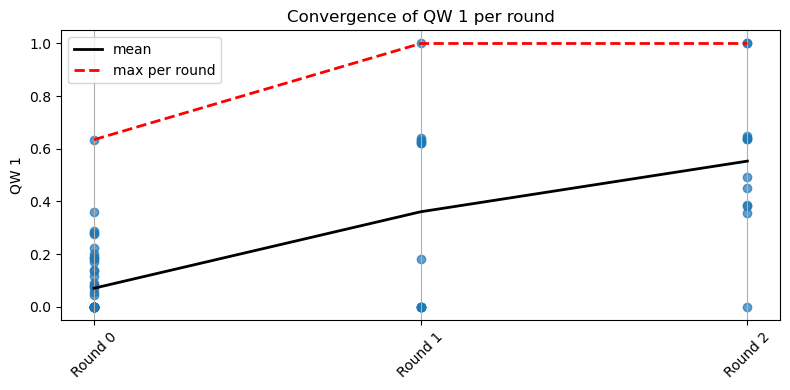

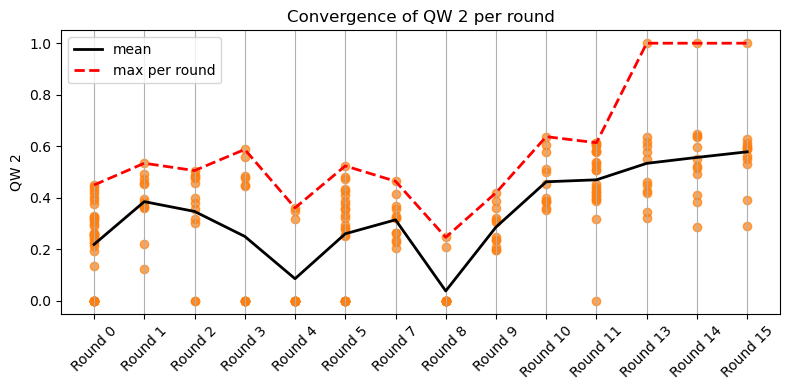

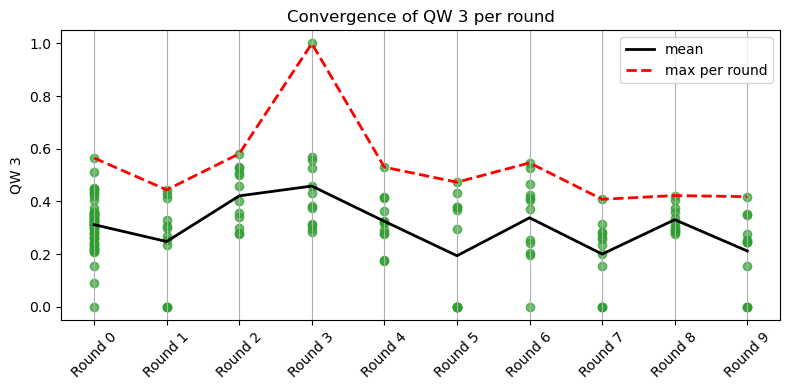

In [73]:
def plot_convergence(data, qw_col, color ='tab:blue'):
    # group data by round extracted from the 'files' column and plot QW 1 per round
    data = data.copy()  # avoid mutating original reference
    data['round'] = data['files'].str.extract(r'R(\d+)', expand=False).astype(int)

    # optional: inspect counts per round to verify R0 has 18 points
    #print("counts per round:\n", data['round'].value_counts().sort_index())

    groups = [g for _, g in data.groupby('round', sort=True)]

    plt.figure(figsize=(8,4))
    for idx, g in enumerate(groups):
        x = np.full(len(g), idx)
        plt.scatter(x, g[qw_col], alpha=0.7, color=color)

    # compute mean and max per round and plot lines
    means = [g[qw_col].mean() for g in groups]
    maxs = [g[qw_col].max() for g in groups]
    x_pos = np.arange(len(groups))
    plt.plot(x_pos, means, marker='', color='k', linestyle='-', linewidth=2, label='mean')
    plt.plot(x_pos, maxs, marker='', color='red', linestyle='--', linewidth=2, label='max per round')
    plt.legend()

    round_labels = [f'Round {r}' for r in sorted(data['round'].unique())]
    plt.xticks(range(len(round_labels)), round_labels, rotation=45)
    plt.ylabel(qw_col)
    plt.title(f'Convergence of {qw_col} per round')
    plt.grid(True)
    plt.grid(False)
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

plot_convergence(N1_data, 'QW 1', 'tab:blue')
plot_convergence(N2_data, 'QW 2', 'tab:orange')
plot_convergence(N3_data, 'QW 3', 'tab:green')


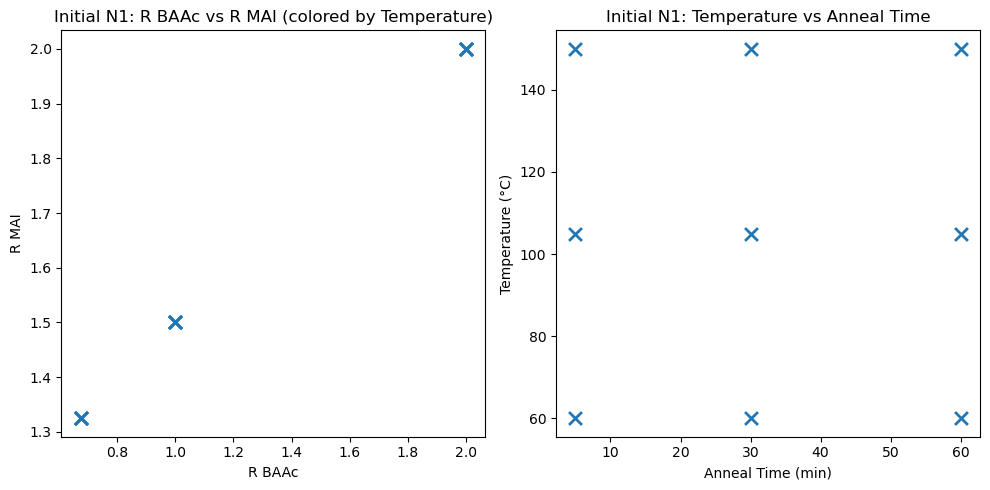

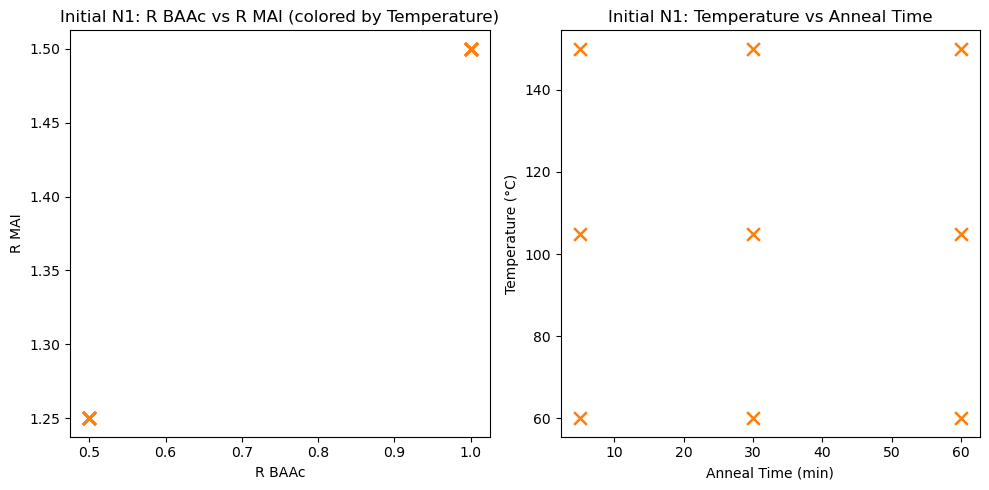

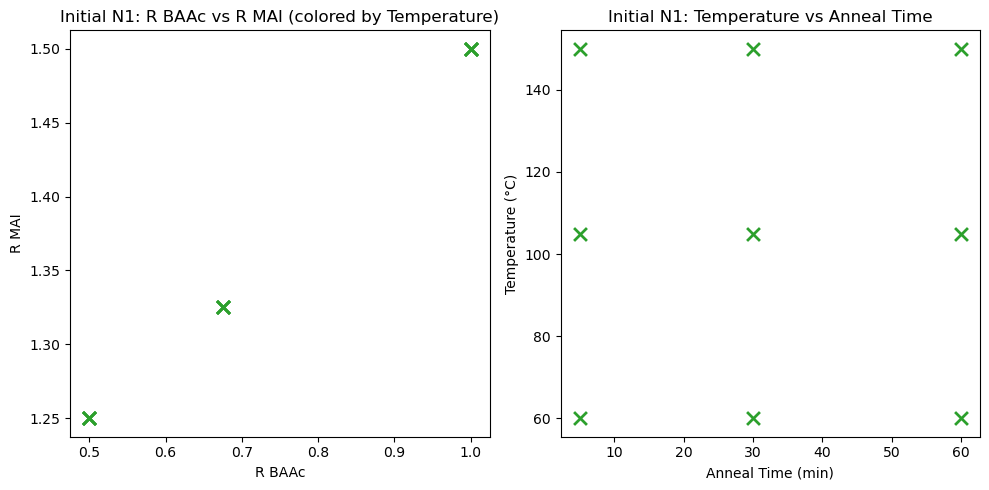

In [74]:
def plot_initial(initial, set_color='tab:blue'):
    # plot two panels side-by-side: (1) R BAAc vs R MAI colored by Temperature, (2) Temperature vs Anneal Time
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    ax1 = axes[0]
    sc = ax1.scatter(initial['R BAAc'], initial['R MAI'], s=80, marker = 'x', alpha=0.9, color = set_color)

    ax1.set_xlabel('R BAAc')
    ax1.set_ylabel('R MAI')
    ax1.set_title('Initial N1: R BAAc vs R MAI (colored by Temperature)')


    ax2 = axes[1]
    ax2.scatter(initial['Anneal Time'], initial['Temperature'], s=80, alpha=0.8, marker='x', color = set_color)
    ax2.set_xlabel('Anneal Time (min)')
    ax2.set_ylabel('Temperature (°C)')
    ax2.set_title('Initial N1: Temperature vs Anneal Time')


    plt.tight_layout()
    plt.show()

plot_initial(N1_data[:54], set_color = 'tab:blue')
plot_initial(N2_data[:36], set_color = 'tab:orange')
plot_initial(N3_data[:54], set_color = 'tab:green')

In [75]:
# Top 10 from each campaing and target
N1_top10 = N1_data.nlargest(10, 'QW 1')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 1', 'files']]
N2_top10 = N2_data.nlargest(10, 'QW 2')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 2', 'files']]
N3_top10 = N3_data.nlargest(10, 'QW 3')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 3', 'files']]


# Combine all data
all_campaigns = pd.concat([N1_data, N2_data, N3_data])


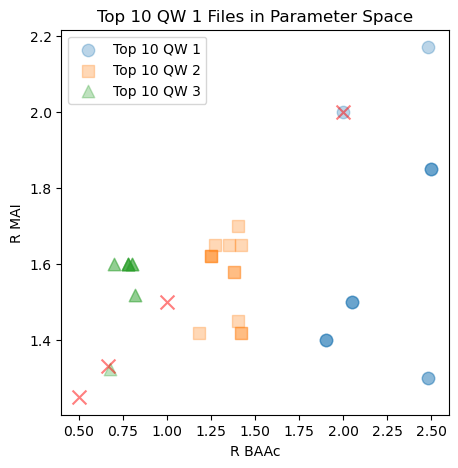

In [90]:
plt.figure(figsize=(5,5))
plt.scatter(N1_top10['R BAAc'], N1_top10['R MAI'], color='tab:blue', s=80, label='Top 10 QW 1', alpha = 0.3)
plt.scatter(N1_top10['R BAAc'].iloc[:3], N1_top10['R MAI'].iloc[:3], color='tab:blue', s=80, alpha = 0.3)

plt.scatter(N2_top10['R BAAc'], N2_top10['R MAI'], color='tab:orange', s=80, label='Top 10 QW 2', alpha = 0.3, marker = 's')
plt.scatter(N2_top10['R BAAc'].iloc[:3], N2_top10['R MAI'].iloc[:3], color='tab:orange', s=80, alpha = 0.3, marker = 's')

plt.scatter(N3_top10['R BAAc'], N3_top10['R MAI'], color='tab:green', s=80, label='Top 10 QW 3', alpha = 0.3, marker = '^')
plt.scatter(N3_top10['R BAAc'].iloc[:3], N3_top10['R MAI'].iloc[:3], color='tab:green', s=80, alpha = 0.3, marker = '^')

plt.scatter(theoretical_N1['R BAAc'], theoretical_N1['R MAI'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N2['R BAAc'], theoretical_N2['R MAI'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N3['R BAAc'], theoretical_N3['R MAI'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N4['R BAAc'], theoretical_N4['R MAI'], marker='x', color='r', s=100, alpha=0.5)


coord_counts = {}
for i, (_, row) in enumerate(N1_top10.iterrows(), start=1):
    key = (round(row['Anneal Time'], 3), round(row['Temperature'], 3))
    count = coord_counts.get(key, 0)
    if count == 0:
        xytext = (5, 5)
        ha = 'center'
        ann_label = str(i)
    else:
        ann_label = ', '+str(i)
        # place duplicate annotations to the right of the previous one, shifting further for each duplicate
        xytext = ( 6*count, 5)
        ha = 'left'
    plt.annotate(ann_label,
                 (row['Anneal Time'], row['Temperature']),
                 fontsize=8,
                 xytext=xytext,
                 textcoords='offset points',
                 ha=ha,
                 color='black')
    coord_counts[key] = count + 1


plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.title('Top 10 QW 1 Files in Parameter Space')
plt.legend()
# plt.tight_layout()
plt.show()



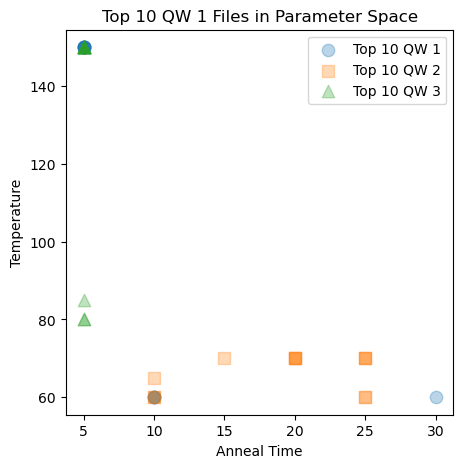

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(N1_top10['Anneal Time'], N1_top10['Temperature'], color='tab:blue', s=80, label='Top 10 QW 1', alpha = 0.3)
plt.scatter(N1_top10['Anneal Time'].iloc[:3], N1_top10['Temperature'].iloc[:3], color='tab:blue', s=80, alpha = 0.3)

plt.scatter(N2_top10['Anneal Time'], N2_top10['Temperature'], color='tab:orange', s=80, label='Top 10 QW 2', alpha = 0.3, marker = 's')
plt.scatter(N2_top10['Anneal Time'].iloc[:3], N2_top10['Temperature'].iloc[:3], color='tab:orange', s=80, alpha = 0.3, marker = 's')

plt.scatter(N3_top10['Anneal Time'], N3_top10['Temperature'], color='tab:green', s=80, label='Top 10 QW 3', alpha = 0.3, marker = '^')
plt.scatter(N3_top10['Anneal Time'].iloc[:3], N3_top10['Temperature'].iloc[:3], color='tab:green', s=80, alpha = 0.3, marker = '^')

# plt.scatter(theoretical_N1['Anneal Time'], theoretical_N1['Temperature'], marker='x', color='r', s=100, alpha=0.5)
# plt.scatter(theoretical_N2['Anneal Time'], theoretical_N2['Temperature'], marker='x', color='r', s=100, alpha=0.5)
# plt.scatter(theoretical_N3['Anneal Time'], theoretical_N3['Temperature'], marker='x', color='r', s=100, alpha=0.5)
# plt.scatter(theoretical_N4['Anneal Time'], theoretical_N4['Temperature'], marker='x', color='r', s=100, alpha=0.5)


plt.xlabel('Anneal Time')
plt.ylabel('Temperature')
plt.title('Top 10 QW 1 Files in Parameter Space')
plt.legend()
# plt.tight_layout()
plt.show()



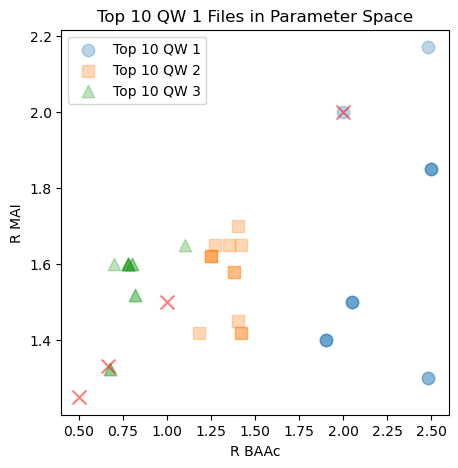

In [80]:
top10_N1 = all_campaigns.nlargest(10, 'QW 1')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 1', 'files']]
top10_N2 = all_campaigns.nlargest(10, 'QW 2')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 2', 'files']]
top10_N3 = all_campaigns.nlargest(10, 'QW 3')[['Anneal Time','Temperature','R BAAc', 'R MAI', 'QW 3', 'files']]

plt.figure(figsize=(5,5))
plt.scatter(top10_N1['R BAAc'], top10_N1['R MAI'], color='tab:blue', s=80, label='Top 10 QW 1', alpha = 0.3)
plt.scatter(top10_N1['R BAAc'].iloc[:3], top10_N1['R MAI'].iloc[:3], color='tab:blue', s=80, alpha = 0.3)

plt.scatter(top10_N2['R BAAc'], top10_N2['R MAI'], color='tab:orange', s=80, label='Top 10 QW 2', alpha = 0.3, marker = 's')
plt.scatter(top10_N2['R BAAc'].iloc[:3], top10_N2['R MAI'].iloc[:3], color='tab:orange', s=80, alpha = 0.3, marker = 's')

plt.scatter(top10_N3['R BAAc'], top10_N3['R MAI'], color='tab:green', s=80, label='Top 10 QW 3', alpha = 0.3, marker = '^')
plt.scatter(top10_N3['R BAAc'].iloc[:3], top10_N3['R MAI'].iloc[:3], color='tab:green', s=80, alpha = 0.3, marker = '^')

plt.scatter(theoretical_N1['R BAAc'], theoretical_N1['R MAI'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N2['R BAAc'], theoretical_N2['R MAI'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N3['R BAAc'], theoretical_N3['R MAI'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N4['R BAAc'], theoretical_N4['R MAI'], marker='x', color='r', s=100, alpha=0.5)


plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.title('Top 10 QW 1 Files in Parameter Space')
plt.legend()
# plt.tight_layout()
plt.show()



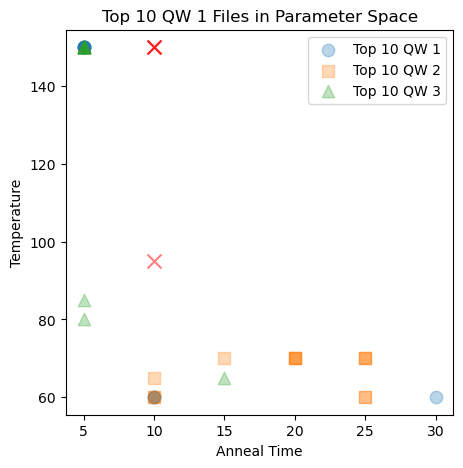

In [83]:
plt.figure(figsize=(5,5))
plt.scatter(top10_N1['Anneal Time'], top10_N1['Temperature'], color='tab:blue', s=80, label='Top 10 QW 1', alpha = 0.3)
plt.scatter(top10_N1['Anneal Time'].iloc[:3], top10_N1['Temperature'].iloc[:3], color='tab:blue', s=80, alpha = 0.3)

plt.scatter(top10_N2['Anneal Time'], top10_N2['Temperature'], color='tab:orange', s=80, label='Top 10 QW 2', alpha = 0.3, marker = 's')
plt.scatter(top10_N2['Anneal Time'].iloc[:3], top10_N2['Temperature'].iloc[:3], color='tab:orange', s=80, alpha = 0.3, marker = 's')

plt.scatter(top10_N3['Anneal Time'], top10_N3['Temperature'], color='tab:green', s=80, label='Top 10 QW 3', alpha = 0.3, marker = '^')
plt.scatter(top10_N3['Anneal Time'].iloc[:3], top10_N3['Temperature'].iloc[:3], color='tab:green', s=80, alpha = 0.3, marker = '^')

plt.scatter(theoretical_N1['Anneal Time'], theoretical_N1['Temperature'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N2['Anneal Time'], theoretical_N2['Temperature'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N3['Anneal Time'], theoretical_N3['Temperature'], marker='x', color='r', s=100, alpha=0.5)
plt.scatter(theoretical_N4['Anneal Time'], theoretical_N4['Temperature'], marker='x', color='r', s=100, alpha=0.5)


plt.xlabel('Anneal Time')
plt.ylabel('Temperature')
plt.title('Top 10 QW 1 Files in Parameter Space')
plt.legend()
# plt.tight_layout()
plt.show()